# Demo 3 Cantielver's Response to oscillating Pulse

We want to use our simulator to simulate cantilever's responese to a oscillating Pulse

In [1]:
import sys
from pathlib import Path
repo_root = Path.cwd().parent   # demo/data → demo → browniansim/
sys.path.insert(0, str(repo_root))
import browniansim as bs

import numpy as np
import matplotlib.pyplot as plt

# Oscillating Pulse

Consider applying a oscillating force on the Cantilever
$\frac{d^2x}{d\tau^2}+\frac{1}{Q}\frac{dx}{d\tau}+x = \frac{F(\tau)}{mw_0^2}$

$F(\tau) = F_0\cos(w/w_0*\tau)$,

We have the equlibrium solution:$x(\tau) = \frac{F_0}{mw_0^2((1-w^2)^2+\frac{w^2}{Q^2})}((1-w^2)\cos(w\tau)+\frac{w}{Q}\sin(w\tau))$

If we want to extract this 2 frequecny, we can do a Fourier transformation, then we gonna see 2 big peaks, one in the positive axis,one in the negative axis,

# Theoritical Response

In [6]:
def response_amp_real(F_0,w,Q):
    return F_0*(1-w**2)/((1-w**2)**2+w**2/Q**2)

def response_amp_imag(F_0,w,Q):
    return 1j*F_0*w/Q/((1-w**2)**2+w**2/Q**2)

def response_amp(F_0,w,Q):
    return F_0/np.sqrt((1-w**2)**2+w**2/Q**2)

c:\Users\top_c\anaconda3\envs\mrfmsim\lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\top_c\anaconda3\envs\mrfmsim\lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


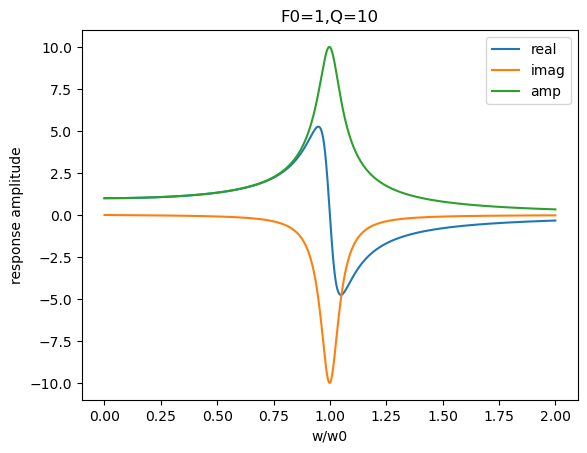

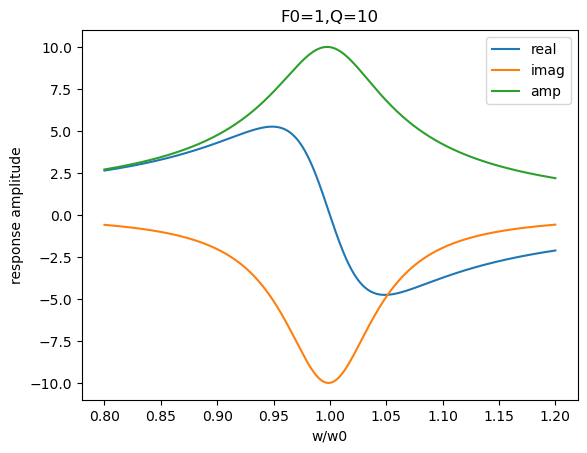

In [7]:
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
dw = np.array([]) # we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)
n = 200.3 # number of cycles in each pulse
dw_l = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)
X0_0 = [0,0]# initial displacement and velocity for simulation

F_0 = 1

w = np.linspace(1-1,1+1,1000)
Q = 10
plt.plot(w,response_amp_real(F_0,w,Q),label='real')
plt.plot(w,1j*(response_amp_imag(F_0,w,Q)),label='imag')
plt.plot(w,response_amp(F_0,w,Q),label='amp')
plt.xlabel('w/w0')
plt.ylabel('response amplitude')
plt.title('F0='+str(F_0)+',Q='+str(Q))
plt.legend()
plt.show()

w = np.linspace(1-2/Q,1+2/Q,1000)

plt.plot(w,response_amp_real(F_0,w,Q),label='real')
plt.plot(w,1j*(response_amp_imag(F_0,w,Q)),label='imag')
plt.plot(w,response_amp(F_0,w,Q),label='amp')
plt.xlabel('w/w0')
plt.ylabel('response amplitude')
plt.title('F0='+str(F_0)+',Q='+str(Q))
plt.legend()
plt.show()

# Simulation

In [3]:
def oscillating_pulse_cos(tau_l,dtau,F_0,w):
    '''
    Generate a oscillating cosine pulse with a duration of tau_0 and a force of F_0 (F/m/w_0^2). As we are using RK4, for time dependent force, we need to sample the force at (t,t+dt/2,t+dt/2,t+dt)
    '''
    return np.array([F_0*np.cos(w*tau_l),F_0*np.cos(w*(tau_l+dtau/2)),F_0*np.cos(w*(tau_l+dtau/2)),F_0*np.cos(w*(tau_l+dtau))]).T



For the oscillating force, we want to have a equlibrium solution, let's set the initial condition to be [0,0], and wait the signal to be equlibrium

--------------------------------
F_0= 1


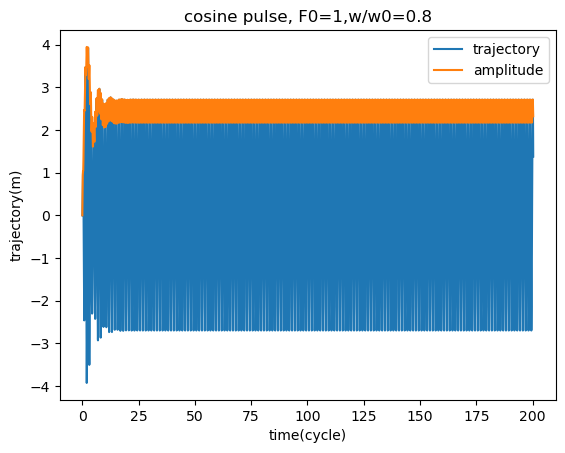

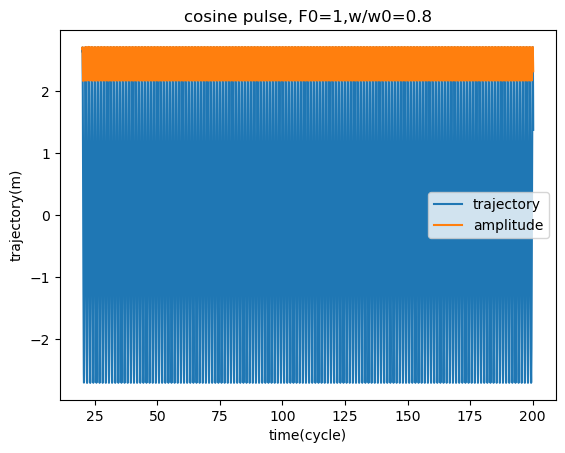

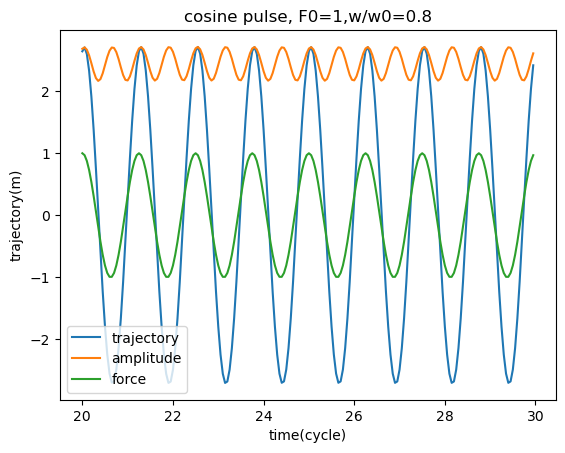

In [4]:
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
dw = np.array([]) # we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)
n = 200.3 # number of cycles in each pulse
dw_l = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)
X0_0 = [0,0]# initial displacement and velocity for simulation
Q=10
w = 0.8
F_0 = 1#the force of the pulse
F_0_l = [1]

n_cut=20#toss the first n_cut cycles

amp_cos_l = []
amp_sin_l = []
for F_0 in F_0_l:
    print('--------------------------------')
    print('F_0=',F_0)
    F_cos = oscillating_pulse_cos(tau_l,dtau,F_0,w)
    signal_cos = bs.solve_RK4(X0_0, dtau, Q, F_cos,dw_l)

    plt.plot(tau_l/2/np.pi, signal_cos[:,0], label='trajectory')
    plt.plot(tau_l/2/np.pi, np.sqrt(signal_cos[:,0]**2+signal_cos[:,1]**2), label='amplitude')
    # plt.plot(tau_l/2/np.pi, F_cos[:,0], label='force')
    plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m)')
    plt.legend()
    plt.show()

    di = int(n_cut*2*np.pi/dtau)
    plt.plot(tau_l[di:]/2/np.pi, signal_cos[di:,0], label='trajectory')
    plt.plot(tau_l[di:]/2/np.pi, np.sqrt(signal_cos[di:,0]**2+signal_cos[di:,1]**2), label='amplitude')
    # plt.plot(tau_l[di:]/2/np.pi, F_cos[di:,0], label='force')
    plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m)')
    plt.legend()
    plt.show()

    i1 = 400
    i2  =600

    plt.plot(tau_l[i1:i2]/2/np.pi, signal_cos[i1:i2,0], label='trajectory')
    plt.plot(tau_l[i1:i2]/2/np.pi, np.sqrt(signal_cos[i1:i2,0]**2+signal_cos[i1:i2,1]**2), label='amplitude')
    plt.plot(tau_l[i1:i2]/2/np.pi, F_cos[i1:i2,0], label='force')
    plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m)')
    plt.legend()
    plt.show()
    






Well, if we forcibly set the initial point of our cantilever to [0,0], we will observe strong oscillations at the initial position, and after about 2/Q cycles, it will tend to stabilize.

--------------------------------
F_0= 1


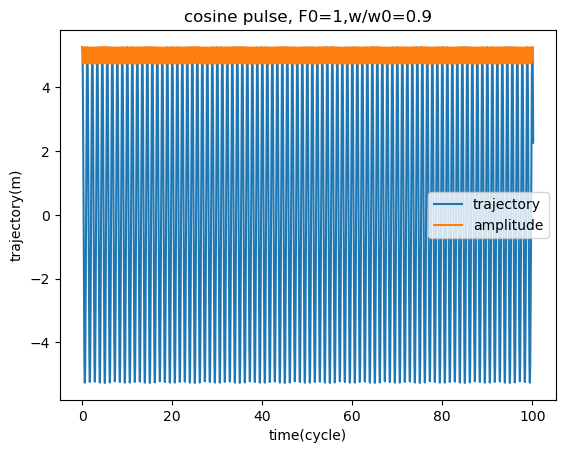

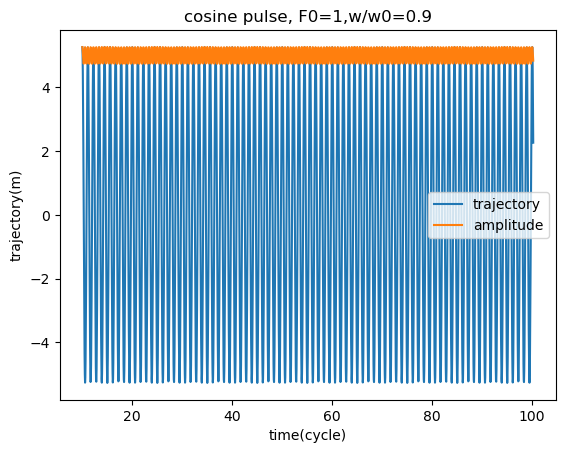

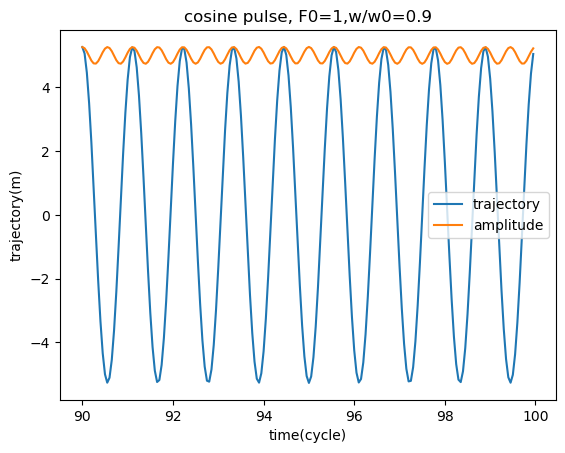

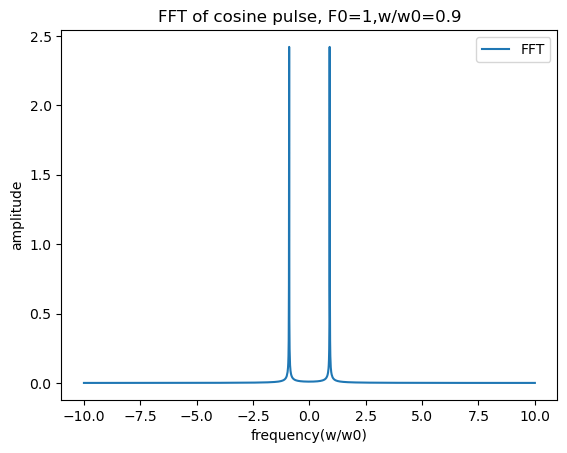

In [8]:
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
dw = np.array([]) # we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)
n = 100.3 # number of cycles in each pulse
dw_l = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)

Q=1000
w = 0.9
F_0 = 10#the force of the pulse
F_0_l = [1]
n_cut=10#toss the first n_cut cycles
amp_cos_l = []
amp_sin_l = []
for F_0 in F_0_l:
    print('--------------------------------')
    print('F_0=',F_0)
    X0_cos = [response_amp_real(F_0,w,Q),np.imag(response_amp_imag(F_0,w,Q))]# initial displacement and velocity for simulation
    F_cos = oscillating_pulse_cos(tau_l,dtau,F_0,w)
    signal_cos = bs.solve_RK4(X0_cos, dtau, Q, F_cos,dw_l)

    plt.plot(tau_l/2/np.pi, signal_cos[:,0], label='trajectory')
    plt.plot(tau_l/2/np.pi, np.sqrt(signal_cos[:,0]**2+signal_cos[:,1]**2), label='amplitude')
    plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m)')
    plt.legend()
    plt.show()

    di = int(n_cut*2*np.pi/dtau)
    plt.plot(tau_l[di:]/2/np.pi, signal_cos[di:,0], label='trajectory')
    plt.plot(tau_l[di:]/2/np.pi, np.sqrt(signal_cos[di:,0]**2+signal_cos[di:,1]**2), label='amplitude')
    plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m)')
    plt.legend()
    plt.show()

    i1 = 1800
    i2  =2000

    plt.plot(tau_l[i1:i2]/2/np.pi, signal_cos[i1:i2,0], label='trajectory')
    plt.plot(tau_l[i1:i2]/2/np.pi, np.sqrt(signal_cos[i1:i2,0]**2+signal_cos[i1:i2,1]**2), label='amplitude')
    plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m)')
    plt.legend()
    plt.show()
    
    sig_fft =np.fft.fftshift(np.fft.fft(signal_cos[:,0])/len(signal_cos[:,0]))
    sig_fft_freq = np.linspace(-1/dtau*2*np.pi/2,1/dtau*2*np.pi/2,len(sig_fft))
    plt.plot(sig_fft_freq,np.abs(sig_fft),label='FFT')
    plt.title('FFT of cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    plt.xlabel('frequency(w/w0)')
    plt.ylabel('amplitude')
    plt.legend()
    plt.show()


    # sig_fft =np.fft.fftshift(np.fft.fft(signal_cos[di:,0])/len(signal_cos[di:,0]))
    # sig_fft_freq = np.linspace(-1/dtau*2*np.pi/2,1/dtau*2*np.pi/2,len(sig_fft))
    # plt.plot(sig_fft_freq,np.(sig_fft),label='FFT')
    # plt.title('FFT of cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'ripped')
    # plt.xlabel('frequency(w/w0)')
    # plt.ylabel('amplitude')
    # plt.legend()
    # plt.show()

    # pkh_1 = np.max(sig_fft[sig_fft_freq>0])
    # pkh_2 = np.max(sig_fft[sig_fft_freq<0])
    # amp_cos_l.append((pkh_1+pkh_2))
    # amp_sin_l.append((pkh_1-pkh_2))

Looks better, let's try to vary the F0

# Varing F0



--------------------------------
F_0= 0.1


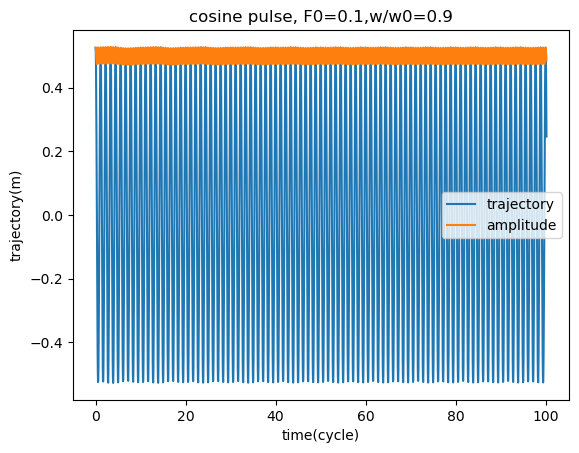

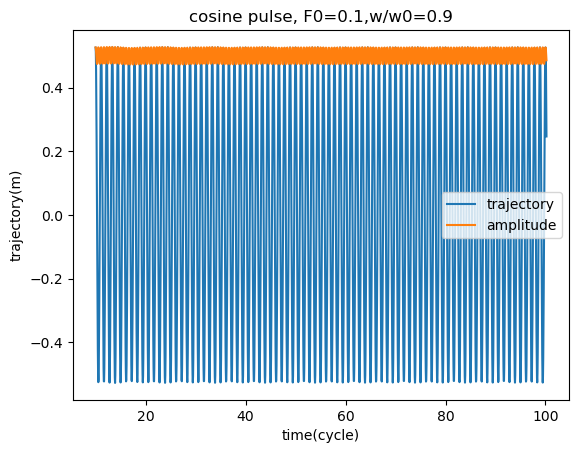

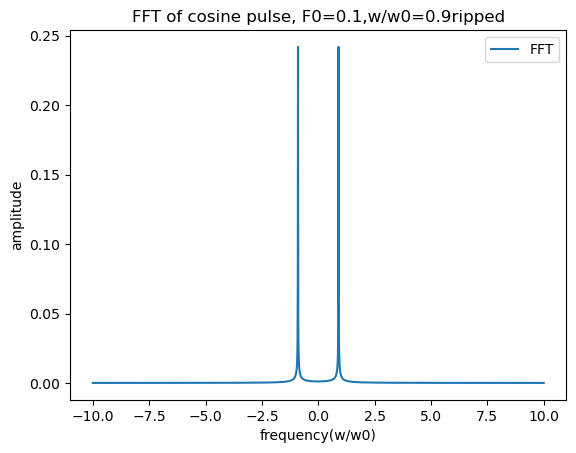

--------------------------------
F_0= 1


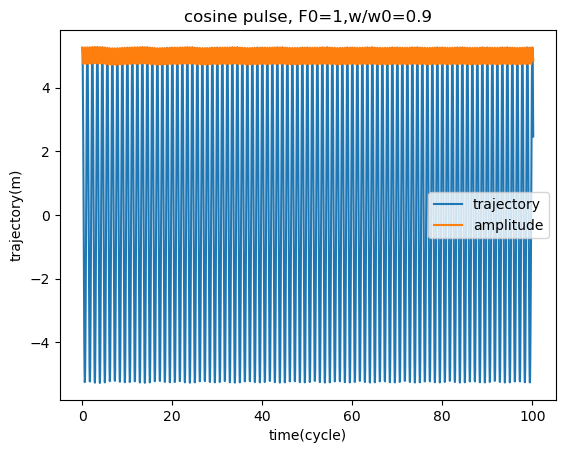

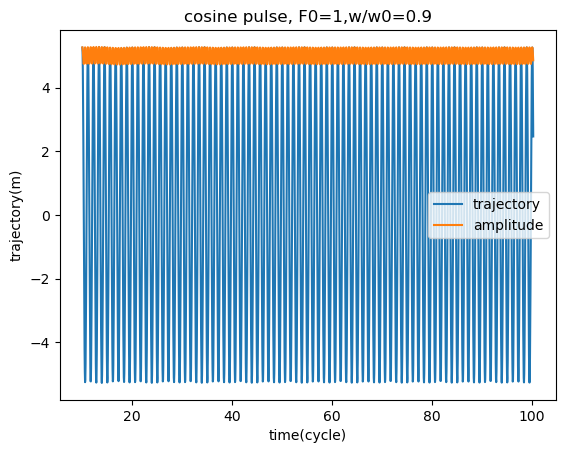

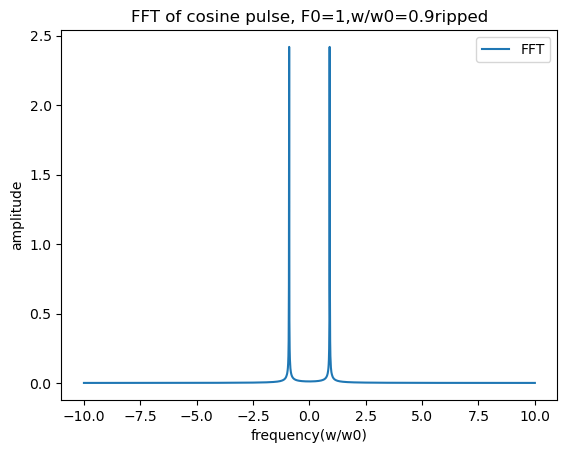

--------------------------------
F_0= 10


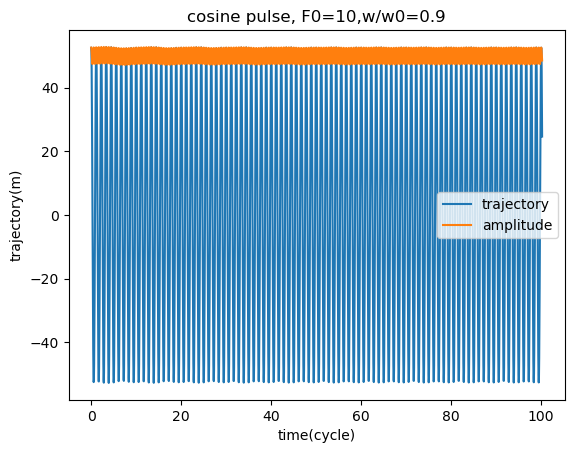

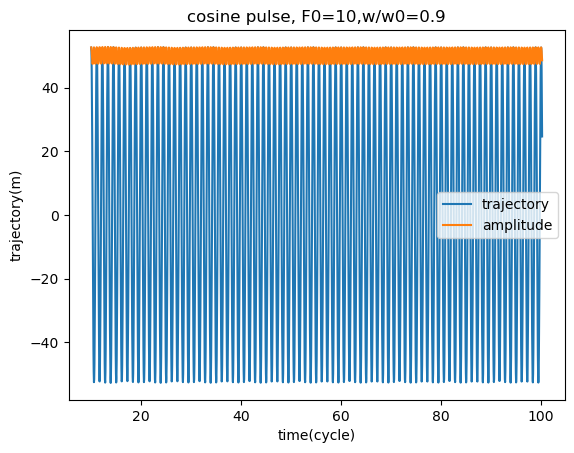

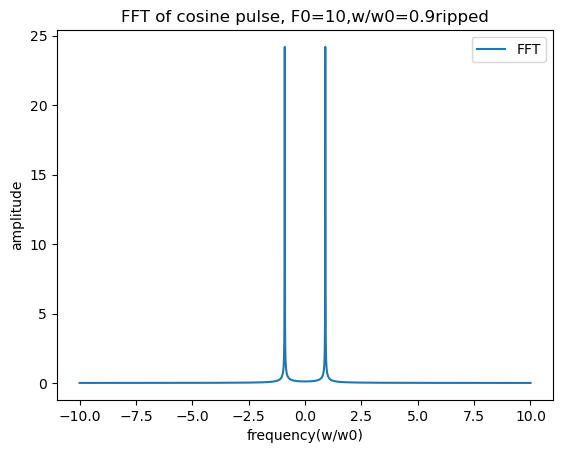

--------------------------------
F_0= 100


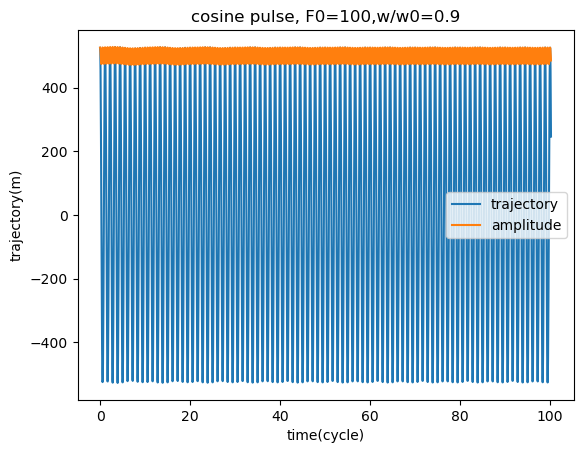

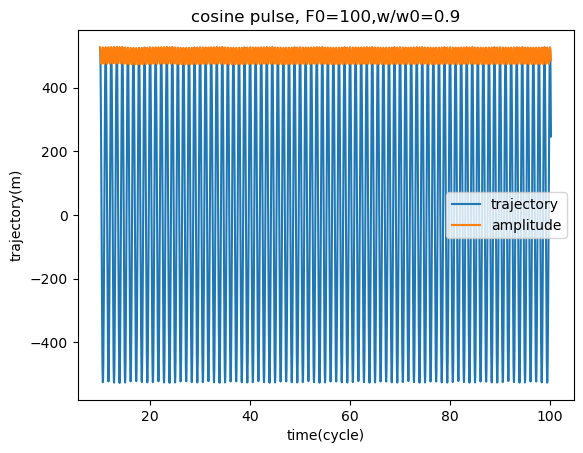

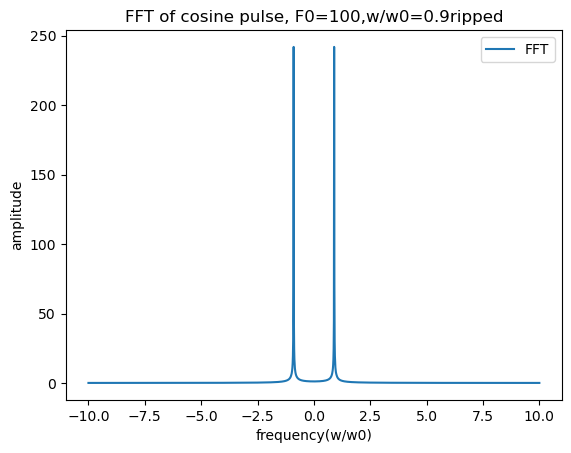

In [10]:
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
dw = np.array([]) # we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)
n = 100.3 # number of cycles in each pulse
dw_l = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)

Q=100
w = 0.9
F_0 = 10#the force of the pulse
F_0_l = [0.1,1,10,100]
n_cut=10#toss the first n_cut cycles
amp_cos_l = []
amp_sin_l = []
for F_0 in F_0_l:
    print('--------------------------------')
    print('F_0=',F_0)
    X0_cos = [response_amp_real(F_0,w,Q),np.imag(response_amp_imag(F_0,w,Q))]# initial displacement and velocity for simulation
    F_cos = oscillating_pulse_cos(tau_l,dtau,F_0,w)
    signal_cos = bs.solve_RK4(X0_cos, dtau, Q, F_cos,dw_l)

    plt.plot(tau_l/2/np.pi, signal_cos[:,0], label='trajectory')
    plt.plot(tau_l/2/np.pi, np.sqrt(signal_cos[:,0]**2+signal_cos[:,1]**2), label='amplitude')
    plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m)')
    plt.legend()
    plt.show()

    di = int(n_cut*2*np.pi/dtau)
    plt.plot(tau_l[di:]/2/np.pi, signal_cos[di:,0], label='trajectory')
    plt.plot(tau_l[di:]/2/np.pi, np.sqrt(signal_cos[di:,0]**2+signal_cos[di:,1]**2), label='amplitude')
    plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m)')
    plt.legend()
    plt.show()

    # i1 = 1800
    # i2  =2000

    # plt.plot(tau_l[i1:i2]/2/np.pi, signal_cos[i1:i2,0], label='trajectory')
    # plt.plot(tau_l[i1:i2]/2/np.pi, np.sqrt(signal_cos[i1:i2,0]**2+signal_cos[i1:i2,1]**2), label='amplitude')
    # plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    # plt.xlabel('time(cycle)')
    # plt.ylabel('trajectory(m)')
    # plt.legend()
    # plt.show()
    
    # sig_fft =np.fft.fftshift(np.fft.fft(signal_cos[:,0])/len(signal_cos[:,0]))
    # sig_fft_freq = np.linspace(-1/dtau*2*np.pi/2,1/dtau*2*np.pi/2,len(sig_fft))
    # plt.plot(sig_fft_freq,np.abs(sig_fft),label='FFT')
    # plt.title('FFT of cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    # plt.xlabel('frequency(w/w0)')
    # plt.ylabel('amplitude')
    # plt.legend()
    # plt.show()


    sig_fft =np.fft.fftshift(np.fft.fft(signal_cos[di:,0])/len(signal_cos[di:,0]))
    sig_fft_freq = np.linspace(-1/dtau*2*np.pi/2,1/dtau*2*np.pi/2,len(sig_fft))
    plt.plot(sig_fft_freq,np.abs(sig_fft),label='FFT')
    plt.title('FFT of cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'ripped')
    plt.xlabel('frequency(w/w0)')
    plt.ylabel('amplitude')
    plt.legend()
    plt.show()

    pkh_1 = np.max(sig_fft[sig_fft_freq>0])
    pkh_2 = np.max(sig_fft[sig_fft_freq<0])
    amp_cos_l.append((pkh_1+pkh_2))
    amp_sin_l.append((pkh_1-pkh_2))

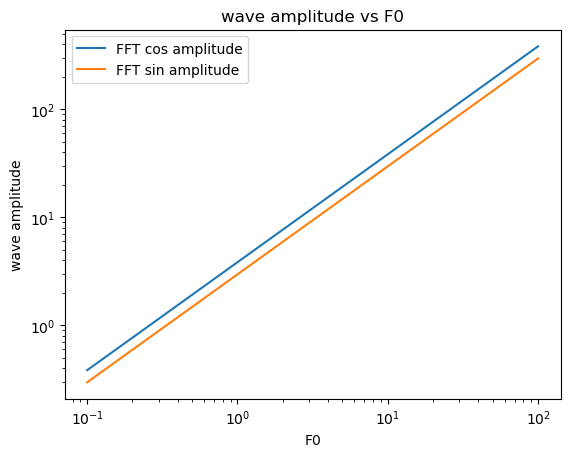

In [11]:
plt.loglog(F_0_l, amp_cos_l, label='FFT cos amplitude')
plt.loglog(F_0_l, np.abs(amp_sin_l), label='FFT sin amplitude')
plt.xlabel('F0')
plt.ylabel('wave amplitude')
plt.title('wave amplitude vs F0')
plt.legend()
plt.show()


Our simulator has successfully reproduced the scaling symmetry with respect to F0

# W

--------------------------------
w= 0.1


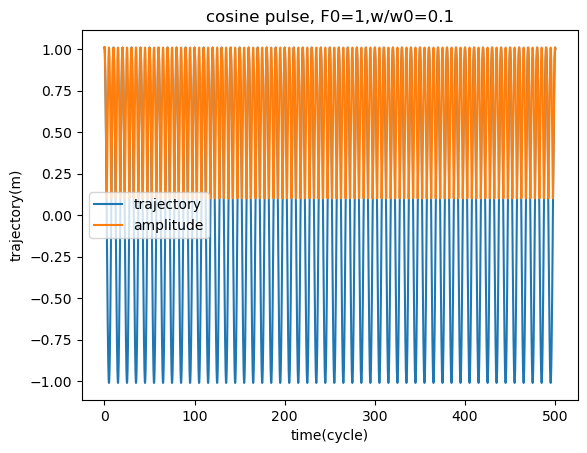

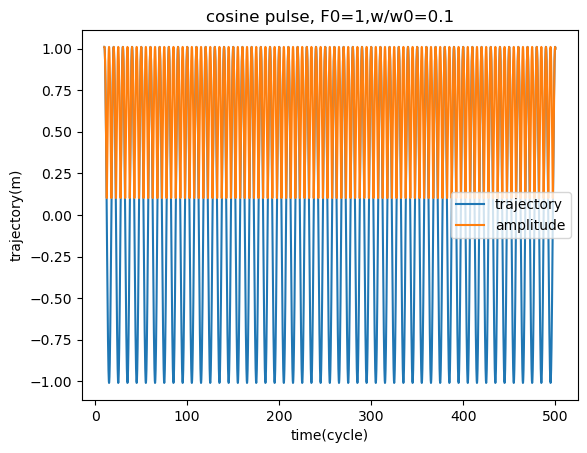

--------------------------------
w= 0.5


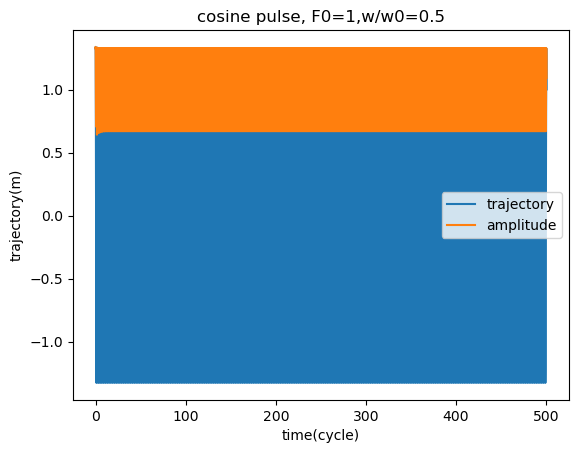

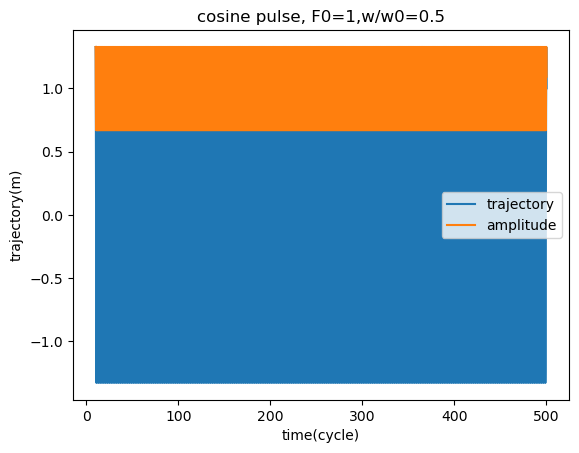

--------------------------------
w= 1


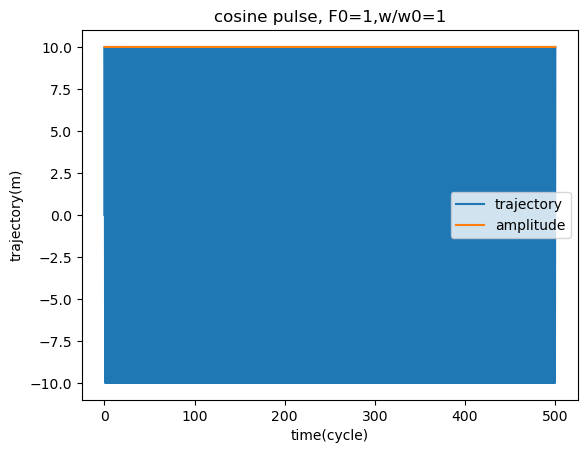

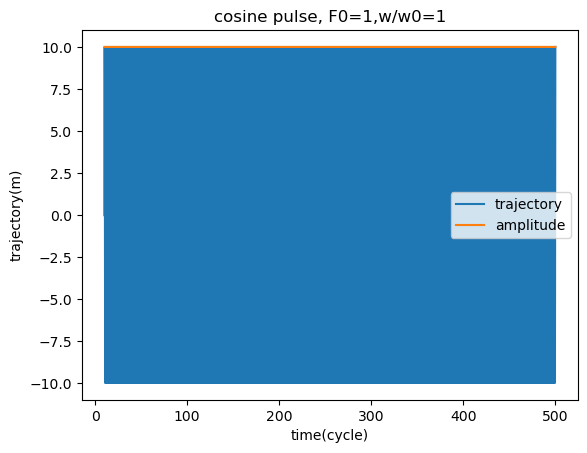

--------------------------------
w= 1.5


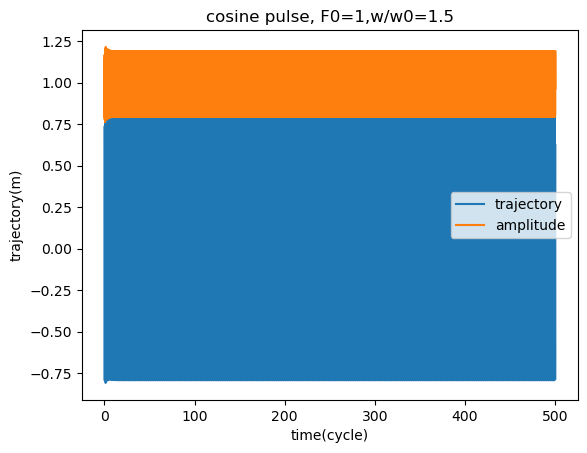

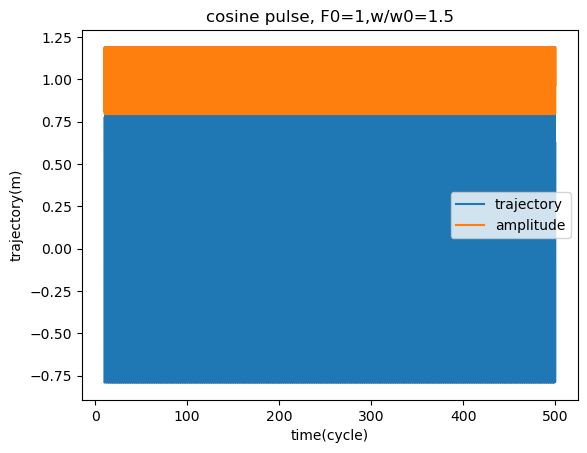

--------------------------------
w= 1.9


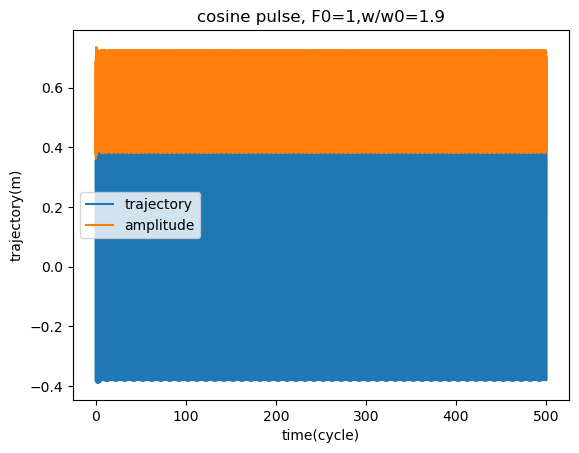

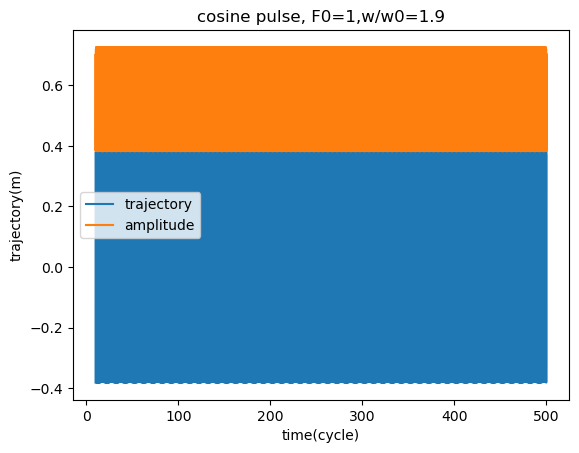

In [12]:
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
dw = np.array([]) # we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)
n = 500.3 # number of cycles in each pulse
dw_l = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)

Q=10
w = 0.9
F_0 = 1#the force of the pulse
w_l = [0.1,0.5,1,1.5,1.9]
n_cut=10#toss the first n_cut cycles
amp_cos_l = []
amp_sin_l = []
for w in w_l:
    print('--------------------------------')
    print('w=',w)
    X0_cos = [response_amp_real(F_0,w,Q),np.imag(response_amp_imag(F_0,w,Q))]# initial displacement and velocity for simulation
    F_cos = oscillating_pulse_cos(tau_l,dtau,F_0,w)
    signal_cos = bs.solve_RK4(X0_cos, dtau, Q, F_cos,dw_l)

    plt.plot(tau_l/2/np.pi, signal_cos[:,0], label='trajectory')
    plt.plot(tau_l/2/np.pi, np.sqrt(signal_cos[:,0]**2+signal_cos[:,1]**2), label='amplitude')
    plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m)')
    plt.legend()
    plt.show()

    di = int(n_cut*2*np.pi/dtau)
    plt.plot(tau_l[di:]/2/np.pi, signal_cos[di:,0], label='trajectory')
    plt.plot(tau_l[di:]/2/np.pi, np.sqrt(signal_cos[di:,0]**2+signal_cos[di:,1]**2), label='amplitude')
    plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m)')
    plt.legend()
    plt.show()

    # i1 = 1800
    # i2  =2000

    # plt.plot(tau_l[i1:i2]/2/np.pi, signal_cos[i1:i2,0], label='trajectory')
    # plt.plot(tau_l[i1:i2]/2/np.pi, np.sqrt(signal_cos[i1:i2,0]**2+signal_cos[i1:i2,1]**2), label='amplitude')
    # plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    # plt.xlabel('time(cycle)')
    # plt.ylabel('trajectory(m)')
    # plt.legend()
    # plt.show()
    
    # sig_fft =np.fft.fftshift(np.fft.fft(signal_cos[:,0])/len(signal_cos[:,0]))
    # sig_fft_freq = np.linspace(-1/dtau*2*np.pi/2,1/dtau*2*np.pi/2,len(sig_fft))
    # plt.plot(sig_fft_freq,np.abs(sig_fft),label='FFT')
    # plt.title('FFT of cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    # plt.xlabel('frequency(w/w0)')
    # plt.ylabel('amplitude')
    # plt.legend()
    # plt.show()


    # sig_fft =np.fft.fftshift(np.fft.fft(signal_cos[di:,0])/len(signal_cos[di:,0]))
    # sig_fft_freq = np.linspace(-1/dtau*2*np.pi/2,1/dtau*2*np.pi/2,len(sig_fft))
    # plt.plot(sig_fft_freq,np.abs(np.real(sig_fft)),label='FFT real')
    # plt.plot(sig_fft_freq,np.abs(np.imag(sig_fft)),label='FFT imag')
    # plt.title('FFT of cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'ripped')
    # plt.xlabel('frequency(w/w0)')
    # plt.ylabel('amplitude')
    # plt.legend()
    # plt.show()

    c = np.cos(w*tau_l)
    s = np.sin(w*tau_l)

    pkh_1 = np.max(np.abs(sig_fft[sig_fft_freq>0]))
    pkh_2 = np.max(np.abs(sig_fft[sig_fft_freq<0]))
    amp_cos_l.append(np.dot(signal_cos[:,0],c)/np.dot(c,c))
    amp_sin_l.append(np.dot(signal_cos[:,0],s)/np.dot(s,s))

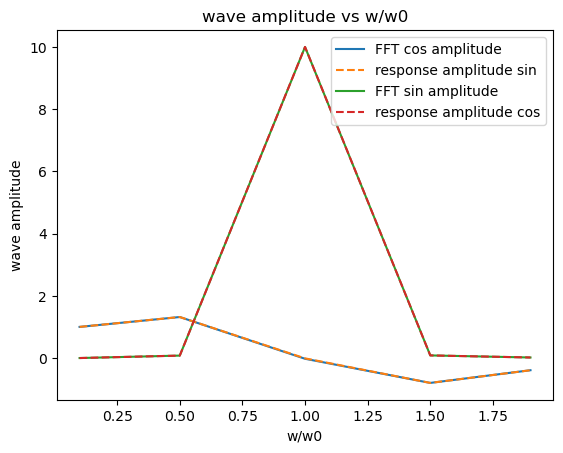

In [14]:
plt.plot(w_l,(amp_cos_l),label='FFT cos amplitude')
plt.plot(np.array(w_l),response_amp_real(F_0,np.array(w_l),Q),linestyle='--',label='response amplitude sin')

plt.plot(w_l,(amp_sin_l),label='FFT sin amplitude')
plt.plot(np.array(w_l),np.imag(response_amp_imag(F_0,np.array(w_l),Q)),linestyle='--',label='response amplitude cos')

plt.xlabel('w/w0')
plt.ylabel('wave amplitude')
plt.title('wave amplitude vs w/w0')
plt.legend()
plt.show()


The trajectory looks stable, let's see more data points

In [15]:
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
dw = np.array([]) # we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)
n = 100.3 # number of cycles in each pulse
dw_l = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)

Q=10

F_0 = 1#the force of the pulse
w_l = [0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5]
n_cut=10#toss the first n_cut cycles
amp_cos_l = []
amp_sin_l = []

for w in w_l:
    print('--------------------------------')
    print('w=',w)
    X0_cos = [response_amp_real(F_0,w,Q),np.imag(response_amp_imag(F_0,w,Q))]# initial displacement and velocity for simulation
    F_cos = oscillating_pulse_cos(tau_l,dtau,F_0,w)
    signal_cos = bs.solve_RK4(X0_cos, dtau, Q, F_cos,dw_l)

    # plt.plot(tau_l/2/np.pi, signal_cos[:,0], label='trajectory')
    # plt.plot(tau_l/2/np.pi, np.sqrt(signal_cos[:,0]**2+signal_cos[:,1]**2), label='amplitude')
    # plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    # plt.xlabel('time(cycle)')
    # plt.ylabel('trajectory(m)')
    # plt.legend()
    # plt.show()

    # di = int(n_cut*2*np.pi/dtau)
    # plt.plot(tau_l[di:]/2/np.pi, signal_cos[di:,0], label='trajectory')
    # plt.plot(tau_l[di:]/2/np.pi, np.sqrt(signal_cos[di:,0]**2+signal_cos[di:,1]**2), label='amplitude')
    # plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    # plt.xlabel('time(cycle)')
    # plt.ylabel('trajectory(m)')
    # plt.legend()
    # plt.show()

    # i1 = 1800
    # i2  =2000

    # plt.plot(tau_l[i1:i2]/2/np.pi, signal_cos[i1:i2,0], label='trajectory')
    # plt.plot(tau_l[i1:i2]/2/np.pi, np.sqrt(signal_cos[i1:i2,0]**2+signal_cos[i1:i2,1]**2), label='amplitude')
    # plt.title('cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    # plt.xlabel('time(cycle)')
    # plt.ylabel('trajectory(m)')
    # plt.legend()
    # plt.show()
    
    # sig_fft =np.fft.fftshift(np.fft.fft(signal_cos[:,0])/len(signal_cos[:,0]))
    # sig_fft_freq = np.linspace(-1/dtau*2*np.pi/2,1/dtau*2*np.pi/2,len(sig_fft))
    # plt.plot(sig_fft_freq,np.abs(sig_fft),label='FFT')
    # plt.title('FFT of cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'')
    # plt.xlabel('frequency(w/w0)')
    # plt.ylabel('amplitude')
    # plt.legend()
    # plt.show()


    # sig_fft =np.fft.fftshift(np.fft.fft(signal_cos[di:,0])/len(signal_cos[di:,0]))
    # sig_fft_freq = np.linspace(-1/dtau*2*np.pi/2,1/dtau*2*np.pi/2,len(sig_fft))
    # plt.plot(sig_fft_freq,np.abs(np.real(sig_fft)),label='FFT real')
    # plt.plot(sig_fft_freq,np.abs(np.imag(sig_fft)),label='FFT imag')
    # plt.title('FFT of cosine pulse, F0='+str(F_0)+',w/w0='+str(w)+'ripped')
    # plt.xlabel('frequency(w/w0)')
    # plt.ylabel('amplitude')
    # plt.legend()
    # plt.show()

    c = np.cos(w*tau_l)
    s = np.sin(w*tau_l)

    pkh_1 = np.max(np.abs(sig_fft[sig_fft_freq>0]))
    pkh_2 = np.max(np.abs(sig_fft[sig_fft_freq<0]))
    amp_cos_l.append(np.dot(signal_cos[:,0],c)/np.dot(c,c))
    amp_sin_l.append(np.dot(signal_cos[:,0],s)/np.dot(s,s))

--------------------------------
w= 0.5
--------------------------------
w= 0.6
--------------------------------
w= 0.7
--------------------------------
w= 0.8
--------------------------------
w= 0.9
--------------------------------
w= 1
--------------------------------
w= 1.1
--------------------------------
w= 1.2
--------------------------------
w= 1.3
--------------------------------
w= 1.4
--------------------------------
w= 1.5


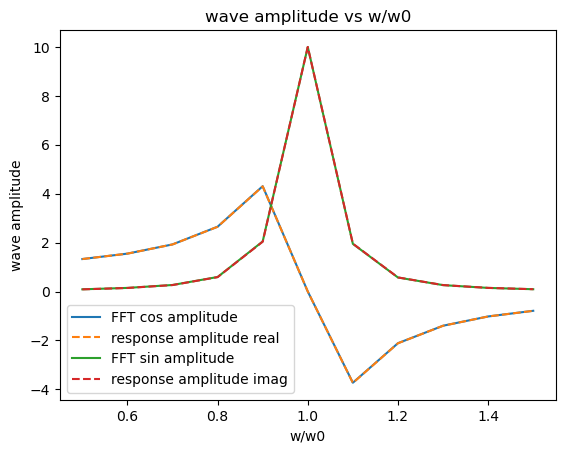

In [16]:
plt.plot(w_l,(amp_cos_l),label='FFT cos amplitude')
plt.plot(np.array(w_l),response_amp_real(F_0,np.array(w_l),Q),linestyle='--',label='response amplitude real')
plt.plot(w_l,(amp_sin_l),label='FFT sin amplitude')
plt.plot(np.array(w_l),np.imag(response_amp_imag(F_0,np.array(w_l),Q)),linestyle='--',label='response amplitude imag')
plt.xlabel('w/w0')
plt.ylabel('wave amplitude')
plt.title('wave amplitude vs w/w0')
plt.legend()
plt.show()

Ok, They fit perfectly. The Last test would be using the real Q to rerun the simulation, and see if the result is the same as the theoretical one.

# Q = 10000

In [17]:
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
dw = np.array([]) # we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)
n = 100.3 # number of cycles in each pulse
dw_l = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)

Q=10000

F_0 = 1#the force of the pulse
w_l = [0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5]
n_cut=10#toss the first n_cut cycles
amp_cos_l = []
amp_sin_l = []

for w in w_l:
    print('--------------------------------')
    print('w=',w)
    X0_cos = [response_amp_real(F_0,w,Q),np.imag(response_amp_imag(F_0,w,Q))]# initial displacement and velocity for simulation
    F_cos = oscillating_pulse_cos(tau_l,dtau,F_0,w)
    signal_cos = bs.solve_RK4(X0_cos, dtau, Q, F_cos,dw_l)

    c = np.cos(w*tau_l)
    s = np.sin(w*tau_l)

    pkh_1 = np.max(np.abs(sig_fft[sig_fft_freq>0]))
    pkh_2 = np.max(np.abs(sig_fft[sig_fft_freq<0]))
    amp_cos_l.append(np.dot(signal_cos[:,0],c)/np.dot(c,c))
    amp_sin_l.append(np.dot(signal_cos[:,0],s)/np.dot(s,s))

--------------------------------
w= 0.5
--------------------------------
w= 0.6
--------------------------------
w= 0.7
--------------------------------
w= 0.8
--------------------------------
w= 0.9
--------------------------------
w= 1
--------------------------------
w= 1.1
--------------------------------
w= 1.2
--------------------------------
w= 1.3
--------------------------------
w= 1.4
--------------------------------
w= 1.5


C:\Users\top_c\AppData\Local\Temp\ipykernel_30576\850830883.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.array(w_l),np.log(np.abs(response_amp_real(F_0,np.array(w_l),Q))),linestyle='--',label='response amplitude real')


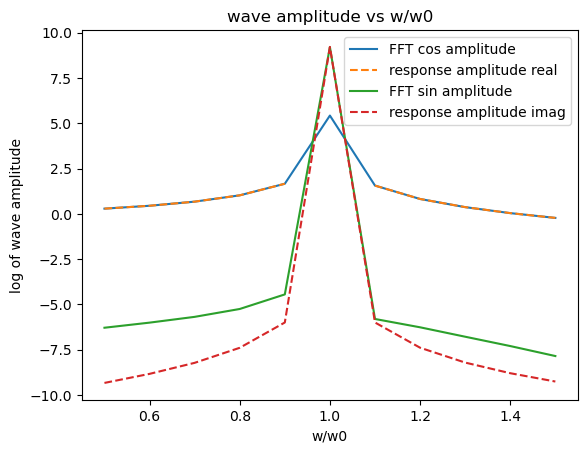

In [18]:
plt.plot(w_l,np.log(np.abs(amp_cos_l)),label='FFT cos amplitude')
plt.plot(np.array(w_l),np.log(np.abs(response_amp_real(F_0,np.array(w_l),Q))),linestyle='--',label='response amplitude real')
plt.plot(w_l,np.log(np.abs(amp_sin_l)),label='FFT sin amplitude')
plt.plot(np.array(w_l),np.log(np.abs(response_amp_imag(F_0,np.array(w_l),Q))),linestyle='--',label='response amplitude imag')
plt.xlabel('w/w0')
plt.ylabel('log of wave amplitude')
plt.title('wave amplitude vs w/w0')
plt.legend()
plt.show()

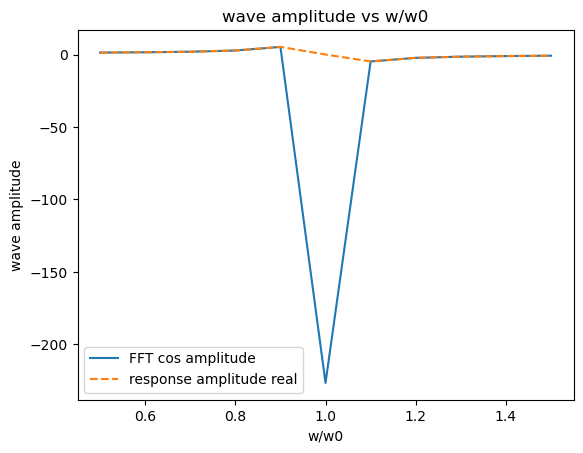

In [19]:
plt.plot(w_l,(amp_cos_l),label='FFT cos amplitude')
plt.plot(np.array(w_l),((response_amp_real(F_0,np.array(w_l),Q))),linestyle='--',label='response amplitude real')
plt.xlabel('w/w0')
plt.ylabel('wave amplitude')
plt.title('wave amplitude vs w/w0')
plt.legend()
plt.show()

Ok,It seems that for High Q, when w is atound w0, the off phase part gonna has some erro,let's run more simulation

In [21]:
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
dw = np.array([]) # we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)
n = 100.3 # number of cycles in each pulse
dw_l = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)

Q=10000

F_0 = 1#the force of the pulse
w_l = [0.98,0.99,0.999,1,1.001,1.01,1.02,]
n_cut=10#toss the first n_cut cycles
amp_cos_l = []
amp_sin_l = []

for w in w_l:
    print('--------------------------------')
    print('w=',w)
    X0_cos = [response_amp_real(F_0,w,Q),np.imag(response_amp_imag(F_0,w,Q))]# initial displacement and velocity for simulation
    F_cos = oscillating_pulse_cos(tau_l,dtau,F_0,w)
    signal_cos = bs.solve_RK4(X0_cos, dtau, Q, F_cos,dw_l)

    c = np.cos(w*tau_l)
    s = np.sin(w*tau_l)

    pkh_1 = np.max(np.abs(sig_fft[sig_fft_freq>0]))
    pkh_2 = np.max(np.abs(sig_fft[sig_fft_freq<0]))
    amp_cos_l.append(np.dot(signal_cos[:,0],c)/np.dot(c,c))
    amp_sin_l.append(np.dot(signal_cos[:,0],s)/np.dot(s,s))

--------------------------------
w= 0.98
--------------------------------
w= 0.99
--------------------------------
w= 0.999
--------------------------------
w= 1
--------------------------------
w= 1.001
--------------------------------
w= 1.01
--------------------------------
w= 1.02


C:\Users\top_c\AppData\Local\Temp\ipykernel_30576\3522069886.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.array(w_l),np.log10(np.abs(response_amp_real(F_0,np.array(w_l),Q))),linestyle='--',label='response amplitude real')


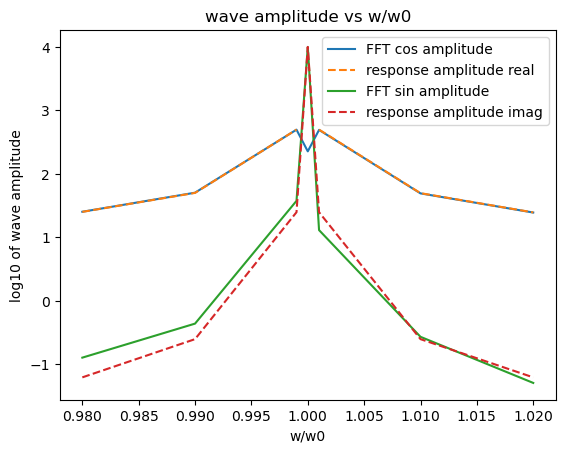

In [22]:
plt.plot(w_l,np.log10(np.abs(amp_cos_l)),label='FFT cos amplitude')
plt.plot(np.array(w_l),np.log10(np.abs(response_amp_real(F_0,np.array(w_l),Q))),linestyle='--',label='response amplitude real')
plt.plot(w_l,np.log10(np.abs(amp_sin_l)),label='FFT sin amplitude')
plt.plot(np.array(w_l),np.log10(np.abs(response_amp_imag(F_0,np.array(w_l),Q))),linestyle='--',label='response amplitude imag')
plt.xlabel('w/w0')
plt.ylabel('log10 of wave amplitude')
plt.title('wave amplitude vs w/w0')
plt.legend()
plt.show()

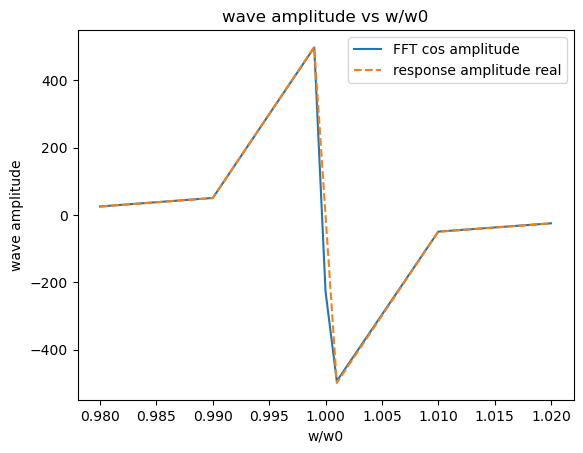

In [23]:
plt.plot(w_l,(amp_cos_l),label='FFT cos amplitude')
plt.plot(np.array(w_l),((response_amp_real(F_0,np.array(w_l),Q))),linestyle='--',label='response amplitude real')
plt.xlabel('w/w0')
plt.ylabel('wave amplitude')
plt.title('wave amplitude vs w/w0')
plt.legend()
plt.show()

Ok, it seems that because w = w0 is a singular point, the fitted trajectory may be shifted away from the true value of 0 due to a small deviation. When Q = 10,000, the magnitude of this shift is about -200.